---
title: "Volatility Forecasts (Part 6: Structured PGARCH Feature Allocation)"
date: 2026-03-10
description: "Part 6 expands the PGARCH feature set and tests channel-specific regularization. The expanded linear variants do not beat the Part 5 baseline, but the diagnostics clarify where richer predictors belong inside the recursion."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 6
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

In [Part 5](../volatility-forecasts-5/) we introduced PGARCH — a predictor-driven GARCH decomposition that separates the variance forecast into a long-run level $\mu_t$, total persistence $\phi_t$, and innovation share $g_t$. The linear variant, `PGARCH-L`, matched `GARCH(1,1)` on out-of-sample QLIKE — the first model in the series to do so — while remaining competitive on RMSE. The result confirmed that the three-channel structure matters, but it was obtained with only three return-based predictors. A natural question follows: do richer predictors push that match toward a clear win, provided they enter the recursion through the right structural channels?

This post tests that question by expanding the PGARCH feature set from 3 to 54 columns — adding HAR realized-volatility summaries, intraday return decompositions, VIX and cross-asset conditions, calendar indicators, and macro-release timing — and fitting five linear PGARCH variants with progressively different channel-specific regularization. The expansion is deliberate: Part 5 showed that the PGARCH scaffold helps; Part 6 asks whether richer information allocated across $\mu$, $\phi$, and $g$ can exploit that scaffold more effectively.

The expanded variants do not beat the Part 5 baseline. Every richer specification improves in-sample fit while losing ground out of sample, and the more freedom given to any channel, the worse the overfitting. The channel diagnostics, however, clarify where the expanded predictors move the recursion and why regularization alone falls short of clean structural allocation. Together, the forecasting evidence and diagnostic evidence point to a nonlinear channel update — rather than another linear reparameterization — as the natural next branch.

The rest of this post builds the feature matrix, defines the model ladder and evaluation standard, fits the PGARCH-L variants and a nonlinear preview, and reads the evidence.

In [1]:
#| echo: false
#| output: false

import sys
import os
import logging
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

# --- PATH SETUP ---
WORKSPACE_CANDIDATES = [
    Path("/Users/steveyang/Projects/steveya"),
    Path("/Users/steveyang/Projects/Github"),
    Path.cwd(),
]
WORKSPACE_ROOT = next(
    (
        p for p in WORKSPACE_CANDIDATES
        if (p / "steveya.github.io").exists()
        and (p / "volatility-forecast").exists()
        and (p / "alphaforge").exists()
    ),
    None,
)
if WORKSPACE_ROOT is None:
    raise RuntimeError(
        "Could not locate a workspace root containing steveya.github.io, volatility-forecast, and alphaforge."
    )

BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
load_dotenv(BLOG_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx, build_vol_dataset, VolDatasetSpec
from volatility_forecast.sources import TiingoEODSource
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.mz import mincer_zarnowitz

from volatility_forecast.model.pgarch_linear_model import PGARCHLinearModel
from volatility_forecast.model.xgb_pgarch_model import XGBGPGARCHModel

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# --- CACHE ---
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/Github/volatility-forecast/.af_cache
Tiingo cache mode: use


In [2]:
#| echo: false
#| output: false

from arch import arch_model
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget

# --- SAMPLE PARAMETERS (identical to Part 5) ---
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")
SAMPLE_TRAIN_START = 200      # warm-up rows discarded
SAMPLE_SPLIT_INDEX = 4000     # train/test boundary
SCALE_FACTOR = 100.0

# --- CACHE PREFLIGHT ---
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)
if sample_cached is None or sample_cached.empty:
    raise RuntimeError(f"Cache-only mode: no cached data for key={sample_cache_key}.")

sample_cached = sample_cached.copy()
sample_cached["date"] = pd.to_datetime(sample_cached["date"], utc=True).dt.normalize()

# --- BUILD DATASET (same spec as Part 5) ---
def _build_spec(source, ticker, start, end, lags=0):
    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=(
            FeatureRequest(
                template=LagLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagAbsLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagSquaredLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
        ),
        target=TargetRequest(
            template=NextDaySquaredReturnTarget(),
            params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
            horizon=1,
            name="y",
        ),
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )

ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)
X_raw, y_raw, r_raw, _ = build_vol_dataset(
    ctx_sample,
    _build_spec("tiingo", SAMPLE_TICKER, SAMPLE_START, SAMPLE_END),
    persist=False,
)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par, y_par, r_par = X_par.loc[common_idx], y_par.loc[common_idx], r_par.loc[common_idx]

# --- FIXED SPLIT ---
X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]
y_all = pd.concat([y_tr, y_te])
r_all = pd.concat([r_tr, r_te])
target_idx = y_par.index

# PGARCH feature columns (no const — model adds its own intercept)
base_feat_cols = [c for c in X_par.columns if c != "const"]

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} -> {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} -> {X_te.index.max().date()})")
print(f"Baseline features: {base_feat_cols}")

Train rows: 3800 (2000-10-18 -> 2015-11-25)
Test rows:  2035 (2015-11-27 -> 2023-12-28)
Baseline features: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10']


## Model Ladder

The PGARCH recursion and its linear parameterization (`PGARCH-L`) are defined in [Part 5](../volatility-forecasts-5/). The key structural detail for this post is that the current `PGARCHLinearModel` passes the **same feature matrix to all three channels** ($\mu$, $\phi$, $g$). Channel-specific regularization — setting different penalty strengths `lambda_mu`, `lambda_phi`, `lambda_g` — is therefore the mechanism through which we steer features toward their intended roles, rather than a hard architectural separation.

The Part 6 ladder tests four steps beyond the Part 5 baseline:

| Step | Model | What changes | Design intent |
|:---|:---|:---|:---|
| 1 | `PGARCH-L` baseline | Part 5 three-feature specification, no regularization | Anchor the experiment to the accepted family baseline |
| 2 | Expanded, uniform shrinkage | 54-feature matrix, common penalties across channels | Does more information help at all? |
| 3 | Structured, rich $\mu$ | 54-feature matrix, loose $\mu$ / moderate $\phi$ / tight $g$ | Does channel-specific allocation help more than uniform expansion? |
| 4 | `XGBPGARCHModel` preview | Boosted channel updates replacing the linear maps | Does a nonlinear channel update outperform the best linear variant? |

The first two steps separate the question of *whether more features help* from the question of *whether they need to be allocated differently*. The third step tests whether letting the level anchor absorb richer information while keeping the innovation share lean is a useful structural prior. The fourth step checks whether the linear branch has exhausted its useful capacity.

## Feature Universe and Taxonomy

The expanded feature matrix contains 54 columns drawn from seven groups: lagged return statistics, intraday return decompositions, HAR multi-horizon realized volatility, downside asymmetry and leverage, volatility-of-volatility, volume and liquidity, calendar and event indicators, and FRED-based cross-asset, stress, and macro-release variables.

The taxonomy below records which channel each feature class is most naturally associated with *before* shrinkage is applied. Fast return and intraday measures are candidates for $g_t$ (innovation share). Volatility-state variables — HAR RV summaries, downside asymmetry, vol-of-vol — are candidates for $\phi_t$ (persistence). Slower state variables — implied-volatility levels, cross-asset conditions, macro timing, liquidity — are candidates for $\mu_t$ (level anchor).

This mapping is a prior, not a constraint. In the current implementation every feature reaches every channel, so the allocation depends entirely on whether differential shrinkage pushes weights in the intended direction.

In [3]:
#| code-fold: true
#| code-summary: "Build expanded feature set (adapted from feature expansion notebook)"

# ──────────────────────────────────────────────────────────────────────────────
# Feature construction pipeline, adapted from the STES/XGBSTES feature expansion
# notebook (posts/volatility-forecasts-7/draft.ipynb).  We reuse the same
# engineering logic to ensure consistency across the series.
# ──────────────────────────────────────────────────────────────────────────────

# ── Shared OHLCV data ────────────────────────────────────────────────────────
ohlcv = sample_cached.set_index("date")[["open", "close", "volume"]].copy()
ohlcv.index = pd.DatetimeIndex(ohlcv.index)
ohlcv = ohlcv.sort_index()
ohlcv_aligned = ohlcv.reindex(target_idx, method="ffill")

# ── 1. Intraday return decomposition ─────────────────────────────────────────
intra_df = pd.DataFrame(index=target_idx)
prev_close = ohlcv_aligned["close"].shift(1)
intra_df["overnight_return"] = np.log(ohlcv_aligned["open"] / prev_close)
intra_df["intraday_return"] = np.log(ohlcv_aligned["close"] / ohlcv_aligned["open"])
intra_df["overnight_sq"] = intra_df["overnight_return"] ** 2
intra_df["intraday_sq"] = intra_df["intraday_return"] ** 2
intra_df = intra_df.fillna(0.0)
intraday_cols = list(intra_df.columns)

# ── 2. HAR multi-horizon realised volatility ─────────────────────────────────
rv_daily = r_par ** 2
har_df = pd.DataFrame(index=target_idx)
har_df["rv_1"] = rv_daily.shift(1)
har_df["rv_5"] = rv_daily.rolling(5, min_periods=1).mean().shift(1)
har_df["rv_22"] = rv_daily.rolling(22, min_periods=1).mean().shift(1)
har_df["rv_60"] = rv_daily.rolling(60, min_periods=1).mean().shift(1)
har_df["rv_ratio_5_22"] = har_df["rv_5"] / har_df["rv_22"].clip(lower=1e-12)
har_df = har_df.fillna(0.0)
har_rv_cols = list(har_df.columns)

# ── 3. Downside asymmetry and leverage effect ────────────────────────────────
neg_mask = (r_par < 0).astype(float)
pos_mask = (r_par >= 0).astype(float)
rv_daily_asym = r_par ** 2

asym_df = pd.DataFrame(index=target_idx)
neg_rv = (rv_daily_asym * neg_mask).rolling(22, min_periods=1).sum().shift(1)
pos_rv = (rv_daily_asym * pos_mask).rolling(22, min_periods=1).sum().shift(1)
asym_df["neg_semi_rv_22"] = neg_rv
asym_df["pos_neg_rv_ratio"] = pos_rv / neg_rv.clip(lower=1e-12)
asym_df["signed_rv_interaction"] = (r_par * rv_daily_asym).shift(1)
asym_df["downside_freq_22"] = neg_mask.rolling(22, min_periods=1).mean().shift(1)
asym_df = asym_df.fillna(0.0)
asym_cols = list(asym_df.columns)

# ── 4. Volatility-of-volatility and regime dispersion ────────────────────────
rv_daily_vov = r_par ** 2
vov_df = pd.DataFrame(index=target_idx)
vov_df["vov_22"] = rv_daily_vov.rolling(22, min_periods=5).std().shift(1)
rv_max_22 = rv_daily_vov.rolling(22, min_periods=5).max().shift(1)
rv_min_22 = rv_daily_vov.rolling(22, min_periods=5).min().shift(1)
vov_df["rv_range_22"] = rv_max_22 - rv_min_22
rv_lag1 = rv_daily_vov.shift(1)
vov_df["rv_autocorr_5"] = rv_daily_vov.rolling(5, min_periods=3).corr(rv_lag1).shift(1)
vov_df = vov_df.fillna(0.0)
vov_cols = list(vov_df.columns)

# ── 5. Volume and liquidity ──────────────────────────────────────────────────
vol_df = pd.DataFrame(index=target_idx)
spy_vol_aligned = ohlcv_aligned["volume"]
spy_close_aligned = ohlcv_aligned["close"]
vol_df["volume_ratio"] = spy_vol_aligned / spy_vol_aligned.rolling(20, min_periods=1).mean()
dollar_volume = spy_close_aligned * spy_vol_aligned
vol_df["amihud_illiq"] = (r_par.abs() / dollar_volume) * 1e6
vol_df = vol_df.fillna(0.0)
volume_cols = list(vol_df.columns)

# ── 6. Calendar and event features ───────────────────────────────────────────
# Deterministic features — no API needed, computed from the trading calendar
try:
    from alphaforge.features import CalendarFlagsTemplate, EventDateTemplate
    from alphaforge.features.template import SliceSpec as AFSliceSpec

    cal_tmpl = CalendarFlagsTemplate()
    cal_slice = AFSliceSpec(start=SAMPLE_START, end=SAMPLE_END, entities=[SAMPLE_TICKER])
    cal_ff = cal_tmpl.transform(
        ctx_sample,
        params={
            "calendar": "XNYS",
            "flags": ("dow", "is_month_end", "is_quarter_end", "is_year_end"),
            "one_hot_dow": True,
        },
        slice=cal_slice,
        state=None,
    )
    if isinstance(cal_ff.index, pd.MultiIndex):
        cal_ff = cal_ff.xs(SAMPLE_TICKER, level="entity_id")
    cal_ff = cal_ff.reindex(target_idx).fillna(0.0)

    evt_tmpl = EventDateTemplate()
    evt_ff = evt_tmpl.transform(
        ctx_sample,
        params={
            "calendar": "XNYS",
            "events": ("fomc", "opex", "imm"),
            "near_window": 3,
        },
        slice=cal_slice,
        state=None,
    )
    if isinstance(evt_ff.index, pd.MultiIndex):
        evt_ff = evt_ff.xs(SAMPLE_TICKER, level="entity_id")
    evt_ff = evt_ff.reindex(target_idx).fillna(0.0)

    seasonal_df = pd.concat([cal_ff, evt_ff], axis=1)
    # Add period-end lead windows
    for col_end in ["is_month_end", "is_quarter_end", "is_year_end"]:
        if col_end in seasonal_df.columns:
            lead_col = col_end.replace("is_", "pre_") + "_3d"
            end_positions = seasonal_df[col_end] == 1
            lead_series = pd.Series(0.0, index=target_idx)
            for idx_pos in end_positions[end_positions].index:
                loc = target_idx.get_loc(idx_pos)
                for lag in range(1, 4):
                    if loc - lag >= 0:
                        lead_series.iloc[loc - lag] = 1.0
            seasonal_df[lead_col] = lead_series
    seasonal_cols = list(seasonal_df.columns)
    _cal_ok = True
    print(f"Calendar/event features: {len(seasonal_cols)} columns")
except Exception as e:
    print(f"Calendar features unavailable ({e}); building minimal DOW flags")
    seasonal_df = pd.DataFrame(index=target_idx)
    dow = target_idx.dayofweek
    for d in range(5):
        seasonal_df[f"dow_{d}"] = (dow == d).astype(float)
    seasonal_cols = list(seasonal_df.columns)
    _cal_ok = False

# ── 7. FRED-based features (VIX, cross-asset, stress, macro) ─────────────────
_fred_ok = False
fred_feature_dfs = []
fred_feature_cols = []
try:
    from fredapi import Fred
    fred = Fred(api_key=os.environ["FRED_API_KEY"])
    _start = SAMPLE_START.strftime("%Y-%m-%d")
    _end = SAMPLE_END.strftime("%Y-%m-%d")

    def _fred_to_daily(s, col_name, tidx):
        s = s.rename(col_name)
        s.index = pd.DatetimeIndex(s.index)
        if tidx.tz is not None:
            s.index = s.index.tz_localize("UTC") if s.index.tz is None else s.index.tz_convert("UTC")
        else:
            s.index = s.index.tz_localize(None) if s.index.tz is not None else s.index
        return s.reindex(tidx, method="ffill")

    # VIX features
    vix_df = pd.DataFrame(index=target_idx)
    vix_series = fred.get_series("VIXCLS", observation_start=_start, observation_end=_end).dropna()
    vix_df["vix_level"] = _fred_to_daily(vix_series, "vix_level", target_idx)
    vix_df["vix_change"] = vix_df["vix_level"].diff().fillna(0.0)
    vix_df["vix_level"] = vix_df["vix_level"].ffill().bfill()
    try:
        vix3m = fred.get_series("VXVCLS", observation_start=_start, observation_end=_end).dropna()
        vix_df["vix_term_slope"] = _fred_to_daily(vix_series, "v1", target_idx) - _fred_to_daily(vix3m, "v2", target_idx)
        vix_df["vix3m_available"] = _fred_to_daily(vix3m, "v3", target_idx).notna().astype(float)
    except Exception:
        vix_df["vix_term_slope"] = 0.0
        vix_df["vix3m_available"] = 0.0
    # IV-RV spread
    rv_20_annualised = np.sqrt(rv_daily.rolling(20, min_periods=5).mean().shift(1) * 252) * 100
    vix_df["iv_rv_spread"] = vix_df["vix_level"] - rv_20_annualised
    vix_df = vix_df.fillna(0.0)
    vix_cols = list(vix_df.columns)
    fred_feature_dfs.append(vix_df[vix_cols])

    # Cross-asset features
    cross_df = pd.DataFrame(index=target_idx)
    fred_cross = {
        "BAMLH0A0HYM2": "credit_spread",
        "T10Y2Y": "curve_slope",
        "DCOILWTICO": "oil_price",
        "DGS2": "short_rate_level",
        "DGS10": "long_rate_level",
        "DTWEXBGS": "usd_level",
    }
    for fred_id, col_name in fred_cross.items():
        try:
            s = fred.get_series(fred_id, observation_start=_start, observation_end=_end).dropna()
            cross_df[col_name] = _fred_to_daily(s, col_name, target_idx)
        except Exception:
            cross_df[col_name] = np.nan

    try:
        copper_monthly = fred.get_series("PCOPPUSDM", observation_start=_start, observation_end=_end).dropna()
        cross_df["copper_level"] = _fred_to_daily(copper_monthly, "copper_level", target_idx)
    except Exception:
        cross_df["copper_level"] = np.nan

    try:
        gld_src = TiingoEODSource(api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"))
        gld_raw = gld_src.fetch(Query(
            table="market.ohlcv", columns=["close"],
            start=SAMPLE_START, end=SAMPLE_END, entities=["GLD"],
        ))
        gld_close = gld_raw.set_index("date")["close"].rename("gold_price")
        if target_idx.tz is None:
            gld_close.index = pd.DatetimeIndex(gld_close.index).tz_localize(None)
        else:
            gld_close.index = pd.DatetimeIndex(gld_close.index).tz_convert(target_idx.tz)
        cross_df["gold_price"] = gld_close.reindex(target_idx, method="ffill")
    except Exception:
        cross_df["gold_price"] = np.nan

    # Derived
    cross_df["gold_return"] = np.log(cross_df["gold_price"] / cross_df["gold_price"].shift(1))
    cross_df["oil_return"] = np.log(cross_df["oil_price"] / cross_df["oil_price"].shift(1))
    cross_df["copper_change"] = cross_df["copper_level"].pct_change()
    cross_df["short_rate_change"] = cross_df["short_rate_level"].diff()
    cross_df["long_rate_change"] = cross_df["long_rate_level"].diff()
    cross_df["usd_change"] = cross_df["usd_level"].pct_change()
    cross_df["usd_available"] = cross_df["usd_level"].notna().astype(float)

    for col in ["credit_spread", "curve_slope", "short_rate_level", "long_rate_level",
                 "usd_level", "copper_level"]:
        cross_df[col] = cross_df[col].ffill().bfill()
    for col in ["gold_return", "oil_return", "copper_change",
                 "short_rate_change", "long_rate_change", "usd_change"]:
        cross_df[col] = cross_df[col].fillna(0.0)
    cross_df["usd_level"] = cross_df["usd_level"].ffill().bfill()
    cross_df = cross_df.drop(columns=["oil_price", "gold_price"], errors="ignore")
    cross_asset_cols = [c for c in cross_df.columns if c not in ("oil_price", "gold_price")]
    cross_df = cross_df[cross_asset_cols].fillna(0.0)
    fred_feature_dfs.append(cross_df)

    # Financial stress
    stress_df = pd.DataFrame(index=target_idx)
    stress_series = {
        "VVIXCLS": "vvix_level",
        "NFCI": "nfci_level",
        "STLFSI4": "stlfsi_level",
        "TEDRATE": "ted_spread",
    }
    for fred_id, col_name in stress_series.items():
        try:
            s = fred.get_series(fred_id, observation_start=_start, observation_end=_end).dropna()
            stress_df[col_name] = _fred_to_daily(s, col_name, target_idx)
        except Exception:
            stress_df[col_name] = np.nan
    stress_df = stress_df.ffill().bfill().fillna(0.0)
    stress_cols = list(stress_df.columns)
    fred_feature_dfs.append(stress_df)

    # Macro release dates
    macro_df = pd.DataFrame(0.0, index=target_idx, columns=[])
    trading_dates = target_idx
    macro_release_series = {"gdp": "GDP", "cpi": "CPIAUCSL", "nfp": "PAYEMS"}
    for label, fred_id in macro_release_series.items():
        try:
            vintages = fred.get_series_vintage_dates(fred_id)
            release_dates = pd.DatetimeIndex(vintages)
            if trading_dates.tz is not None:
                release_dates = release_dates.tz_localize("UTC") if release_dates.tz is None else release_dates.tz_convert("UTC")
            else:
                release_dates = release_dates.tz_localize(None) if release_dates.tz is not None else release_dates
            release_dates = release_dates.normalize()
            macro_df[f"is_{label}_release"] = trading_dates.isin(release_dates).astype(float)
            # Pre-release 1d indicator (aligned to forecast date t+1)
            pre_col = f"pre_{label}_1d"
            shifted_releases = release_dates - pd.tseries.offsets.BDay(1)
            macro_df[pre_col] = trading_dates.isin(shifted_releases).astype(float)
        except Exception as e:
            print(f"  Macro release {label} unavailable: {e}")
            macro_df[f"is_{label}_release"] = 0.0
            macro_df[f"pre_{label}_1d"] = 0.0
    macro_cols = list(macro_df.columns)
    fred_feature_dfs.append(macro_df)

    _fred_ok = True
    for _df in fred_feature_dfs:
        fred_feature_cols.extend(list(_df.columns))
    print(f"FRED-based features: {len(fred_feature_cols)} columns")
except Exception as e:
    print(f"FRED features unavailable ({e}); proceeding without them")
    _fred_ok = False

# ── Assemble the expanded feature matrix ─────────────────────────────────────
# Start with the baseline return features (no const)
expanded_parts = [X_par[base_feat_cols]]

# Return-derived features (always available)
expanded_parts.extend([intra_df, har_df, asym_df, vov_df, vol_df])

# Calendar features (usually available)
expanded_parts.append(seasonal_df)

# FRED features (if available)
if _fred_ok:
    expanded_parts.extend(fred_feature_dfs)

X_expanded = pd.concat(expanded_parts, axis=1)
X_expanded = X_expanded.fillna(0.0)

# Remove any duplicate columns
X_expanded = X_expanded.loc[:, ~X_expanded.columns.duplicated()]

expanded_feat_cols = list(X_expanded.columns)

# Split
X_exp_tr = X_expanded.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_exp_te = X_expanded.iloc[SAMPLE_SPLIT_INDEX:]
X_exp_all = pd.concat([X_exp_tr, X_exp_te])

print(f"\nExpanded feature matrix: {X_expanded.shape[1]} columns")
print(f"  Return-based:       {len(base_feat_cols)}")
print(f"  Intraday decomp:    {len(intraday_cols)}")
print(f"  HAR-RV:             {len(har_rv_cols)}")
print(f"  Asymmetry:          {len(asym_cols)}")
print(f"  Vol-of-vol:         {len(vov_cols)}")
print(f"  Volume/liquidity:   {len(volume_cols)}")
print(f"  Calendar/event:     {len(seasonal_cols)}")
if _fred_ok:
    print(f"  FRED-based:         {len(fred_feature_cols)}")
print(f"  Train: {X_exp_tr.shape}, Test: {X_exp_te.shape}")

Calendar features unavailable ('FeatureFrame' object has no attribute 'index'); building minimal DOW flags


/Users/steveyang/miniforge3/envs/py312/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


FRED-based features: 28 columns

Expanded feature matrix: 54 columns
  Return-based:       3
  Intraday decomp:    4
  HAR-RV:             5
  Asymmetry:          4
  Vol-of-vol:         3
  Volume/liquidity:   2
  Calendar/event:     5
  FRED-based:         28
  Train: (3800, 54), Test: (2035, 54)


In [4]:
#| code-fold: true
#| code-summary: "Feature allocation taxonomy"

def _assign_channel(feat_name):
    '''Assign a primary PGARCH channel based on the feature economic role.'''
    f = feat_name.lower()

    # g-channel: fast shock features
    g_features = {"overnight_return", "intraday_return", "overnight_sq", "intraday_sq",
                   "signed_rv_interaction"}
    if f in g_features:
        return "g (innovation)"
    if any(k in f for k in ["logret", "log_return"]):
        return "g (innovation)"

    # phi-channel: persistence features
    phi_features = {"rv_autocorr_5", "vov_22", "rv_range_22", "rv_ratio_5_22",
                    "neg_semi_rv_22", "pos_neg_rv_ratio", "downside_freq_22",
                    "rv_5", "rv_22", "rv_60", "rv_1"}
    if f in phi_features:
        return "phi (persistence)"

    # Everything else -> mu-channel
    return "mu (level)"


def _assign_group(feat_name):
    '''Assign a feature group label.'''
    f = feat_name.lower()
    if any(k in f for k in ["logret", "log_return"]):
        return "Return-based"
    if f.startswith("dow_"):
        return "Calendar (DOW)"
    if any(k in f for k in ["month_end", "quarter_end", "year_end"]):
        return "Calendar (Period-end)"
    if any(k in f for k in ["fomc", "opex", "imm"]):
        return "Calendar (Events)"
    if any(k in f for k in ["vix", "iv_rv", "vix3m"]):
        return "VIX / Implied Vol"
    if any(k in f for k in ["credit", "curve", "gold", "oil", "rate", "usd", "copper"]):
        return "Cross-Asset"
    if any(k in f for k in ["volume", "amihud"]):
        return "Volume / Liquidity"
    if any(k in f for k in ["gdp", "cpi", "nfp"]):
        return "Macro Release"
    if any(k in f for k in ["overnight", "intraday"]):
        return "Intraday Decomp"
    if any(k in f for k in ["rv_", "neg_semi", "downside", "signed_rv",
                             "vov_", "nfci", "stlfsi", "ted", "vvix"]):
        return "Volatility State"
    return "Other"


taxonomy = pd.DataFrame({
    "Feature": expanded_feat_cols,
    "Group": [_assign_group(f) for f in expanded_feat_cols],
    "Channel": [_assign_channel(f) for f in expanded_feat_cols],
})

channel_summary = taxonomy.groupby("Channel")["Feature"].count().rename("Count")
group_summary = taxonomy.groupby(["Channel", "Group"])["Feature"].count().rename("Count")
print("Channel allocation summary:")
print(channel_summary.to_string())
print()
print("Detailed group × channel:")
print(group_summary.to_string())

display(style_results_table(taxonomy, precision=0, index_col="Feature"))

Channel allocation summary:
Channel
g (innovation)        8
mu (level)           35
phi (persistence)    11

Detailed group × channel:
Channel            Group             
g (innovation)     Intraday Decomp        4
                   Return-based           3
                   Volatility State       1
mu (level)         Calendar (DOW)         5
                   Cross-Asset           13
                   Macro Release          6
                   VIX / Implied Vol      6
                   Volatility State       3
                   Volume / Liquidity     2
phi (persistence)  Volatility State      11


,Group,Channel
Feature,,
lag.logret.fc5d3612d9c7,Return-based,g (innovation)
lag.abslogret.1ad490bcb584,Return-based,g (innovation)
lag.sqlogret.c2cf3aa70c10,Return-based,g (innovation)
overnight_return,Intraday Decomp,g (innovation)
intraday_return,Intraday Decomp,g (innovation)
overnight_sq,Intraday Decomp,g (innovation)
intraday_sq,Intraday Decomp,g (innovation)
rv_1,Volatility State,phi (persistence)
rv_5,Volatility State,phi (persistence)


## Evaluation Standard

The dataset, target, and split are held fixed from Part 5: 3,800 training observations and 2,035 out-of-sample observations on SPY daily squared returns, January 2000 through December 2023. `GARCH(1,1)` remains the benchmark and the Part 5 `PGARCH-L` baseline remains the active family reference. The decision rule is the same as in Parts 4 and 5: lower out-of-sample QLIKE than `GARCH(1,1)`, with Diebold-Mariano tests on QLIKE loss differentials to judge statistical credibility. RMSE is a secondary diagnostic.

The model implementations live in the sibling `volatility-forecast` repository: `pgarch_linear_model.py` for the linear branch and `xgb_pgarch_full_model.py` for the nonlinear preview.

### Part 6 Variants

We define five linear PGARCH variants that walk one step at a time through the expanded-feature question:

| Model | Features | `lambda_mu` | `lambda_phi` | `lambda_g` | Design intent |
|:---|:---|:---:|:---:|:---:|:---|
| **A** — Part 5 baseline | 3 return features | 0 | 0 | 0 | Reproduce the Part 5 `PGARCH-L` reference |
| **B** — Expanded, uniform | All 54 | 0.01 | 0.01 | 0.01 | Does all-feature expansion help at all? |
| **C** — Structured, rich $\mu$ | All 54 | 0.001 | 0.01 | 0.1 | Main channel-allocation test |
| **D** — Structured, very rich $\mu$ | All 54 | 0.0001 | 0.01 | 0.1 | Does extra $\mu$ freedom help or overfit? |
| **E** — Structured, relaxed $g$ | All 54 | 0.001 | 0.01 | 0.01 | Does the innovation channel benefit from broader access? |

Model B vs A tests whether expansion helps. C vs B tests whether structured allocation outperforms uniform shrinkage. D vs C tests whether more $\mu$ freedom is useful or costly. E vs C tests whether a lean $g$ channel is a helpful prior or an unnecessary restriction.

In [5]:
#| code-fold: true
#| code-summary: "Fit GARCH(1,1) baseline"

r_tr_pct = r_tr * SCALE_FACTOR
r_all_concat = pd.concat([r_tr, r_te])
r_all_pct = r_all_concat * SCALE_FACTOR

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")
omega_g, alpha_g, beta_g = (
    garch_fit.params["omega"],
    garch_fit.params["alpha[1]"],
    garch_fit.params["beta[1]"],
)

cv_sq_is = garch_fit.conditional_volatility.values ** 2
r_sq_is = r_tr_pct.values ** 2
garch_pred_is = (omega_g + alpha_g * r_sq_is + beta_g * cv_sq_is) / (SCALE_FACTOR ** 2)

garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=len(r_tr))
garch_fcast = garch_fit_full.forecast(start=len(r_tr), reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (SCALE_FACTOR ** 2)

print(f"GARCH(1,1): omega={omega_g:.6f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}")

GARCH(1,1): omega=0.018841, alpha=0.0952, beta=0.8899


In [6]:
#| code-fold: true
#| code-summary: "Fit PGARCH-L model ladder (Models A–E)"

RANDOM_STATE = 42

# ── Model A: Part 5 baseline (3 return features, no regularisation) ──────────
X_base_tr = X_tr[base_feat_cols]
X_base_te = X_te[base_feat_cols]
X_base_all = pd.concat([X_base_tr, X_base_te])

model_a = PGARCHLinearModel(loss="qlike", random_state=RANDOM_STATE)
model_a.fit(y_tr.values, X_base_tr.values)
h_a = model_a.predict_variance(y_all.values, X_base_all.values)
h_a_is, h_a_os = h_a[: len(y_tr)], h_a[len(y_tr) :]
print(f"Model A (Part 5 baseline):  train QLIKE = {model_a.train_loss_:.6f}")

# ── Model B: Expanded features, uniform regularisation ───────────────────────
model_b = PGARCHLinearModel(
    loss="qlike",
    lambda_mu=0.01, lambda_phi=0.01, lambda_g=0.01,
    random_state=RANDOM_STATE,
)
model_b.fit(y_tr.values, X_exp_tr.values)
h_b = model_b.predict_variance(y_all.values, X_exp_all.values)
h_b_is, h_b_os = h_b[: len(y_tr)], h_b[len(y_tr) :]
print(f"Model B (uniform reg):      train QLIKE = {model_b.train_loss_:.6f}")

# ── Model C: Structured (rich mu, lean g) ────────────────────────────────────
model_c = PGARCHLinearModel(
    loss="qlike",
    lambda_mu=0.001, lambda_phi=0.01, lambda_g=0.1,
    random_state=RANDOM_STATE,
)
model_c.fit(y_tr.values, X_exp_tr.values)
h_c = model_c.predict_variance(y_all.values, X_exp_all.values)
h_c_is, h_c_os = h_c[: len(y_tr)], h_c[len(y_tr) :]
print(f"Model C (rich mu, lean g):  train QLIKE = {model_c.train_loss_:.6f}")

# ── Model D: Structured (very rich mu) ───────────────────────────────────────
model_d = PGARCHLinearModel(
    loss="qlike",
    lambda_mu=0.0001, lambda_phi=0.01, lambda_g=0.1,
    random_state=RANDOM_STATE,
)
model_d.fit(y_tr.values, X_exp_tr.values)
h_d = model_d.predict_variance(y_all.values, X_exp_all.values)
h_d_is, h_d_os = h_d[: len(y_tr)], h_d[len(y_tr) :]
print(f"Model D (very rich mu):     train QLIKE = {model_d.train_loss_:.6f}")

# ── Model E: Structured (relaxed g) ──────────────────────────────────────────
model_e = PGARCHLinearModel(
    loss="qlike",
    lambda_mu=0.001, lambda_phi=0.01, lambda_g=0.01,
    random_state=RANDOM_STATE,
)
model_e.fit(y_tr.values, X_exp_tr.values)
h_e = model_e.predict_variance(y_all.values, X_exp_all.values)
h_e_is, h_e_os = h_e[: len(y_tr)], h_e[len(y_tr) :]
print(f"Model E (relaxed g):        train QLIKE = {model_e.train_loss_:.6f}")

print("\nAll PGARCH-L variants fitted.")

Model A (Part 5 baseline):  train QLIKE = -8.284038
Model B (uniform reg):      train QLIKE = -8.338864
Model C (rich mu, lean g):  train QLIKE = -8.340562
Model D (very rich mu):     train QLIKE = -8.344309
Model E (relaxed g):        train QLIKE = -8.344765

All PGARCH-L variants fitted.


In [7]:
#| label: performance-table
#| tbl-cap: "Out-of-sample performance: GARCH(1,1) vs PGARCH-L variants"

actual_is = y_tr.values
actual_os = y_te.values

model_predictions = {
    "GARCH(1,1)":              (garch_pred_is,  garch_pred_os),
    "A: PGARCH-L baseline":    (h_a_is,         h_a_os),
    "B: Expanded uniform":     (h_b_is,         h_b_os),
    "C: Structured (rich mu)": (h_c_is,         h_c_os),
    "D: Structured (very rich mu)": (h_d_is,    h_d_os),
    "E: Structured (relaxed g)":    (h_e_is,    h_e_os),
}

rows = []
for name, (pred_is, pred_os) in model_predictions.items():
    rows.append({
        "Model": name,
        "IS RMSE": rmse(actual_is, pred_is),
        "OS RMSE": rmse(actual_os, pred_os),
        "IS QLIKE": qlike(actual_is, pred_is),
        "OS QLIKE": qlike(actual_os, pred_os),
    })

results_df = pd.DataFrame(rows).set_index("Model")

# Highlight the best OS scores
display(style_results_table(results_df, precision=6, index_col="Model"))

,IS RMSE,OS RMSE,IS QLIKE,OS QLIKE
Model,,,,
"GARCH(1,1)",0.000504,0.000460,1.513060,1.561044
A: PGARCH-L baseline,0.000483,0.000459,1.456357,1.550144
B: Expanded uniform,0.000462,0.000855,1.401546,1.604755
C: Structured (rich mu),0.000464,0.001051,1.399849,1.625556
D: Structured (very rich mu),0.000456,0.000949,1.396102,1.830423
E: Structured (relaxed g),0.000473,0.001533,1.395647,1.616961


## Analysis

**The Part 5 baseline holds.** Model A posts the best OS QLIKE (1.550) among all variants, edging out `GARCH(1,1)` (1.561) — the same directional improvement reported in Part 5. No expanded specification matches it.

**Expanded features overfit.** Models B through E all improve in-sample fit relative to Model A, yet each one is worse out of sample. The pattern is monotonic in freedom: Model D, which gives the level channel the most latitude, produces the worst OS QLIKE (1.830). Richer information improves the training-set likelihood without improving the forecast.

**Channel-specific shrinkage does not rescue the expansion.** Model C (structured allocation) is worse than Model B (uniform shrinkage), and Model E (relaxed $g$) sits between them. The differential-penalty idea does not compensate for the variance cost of a 54-column linear design.

We now formalize these comparisons with Diebold-Mariano tests and then examine the structural diagnostics to understand *why* the expanded models fail and *where* the richer features plausibly belong.

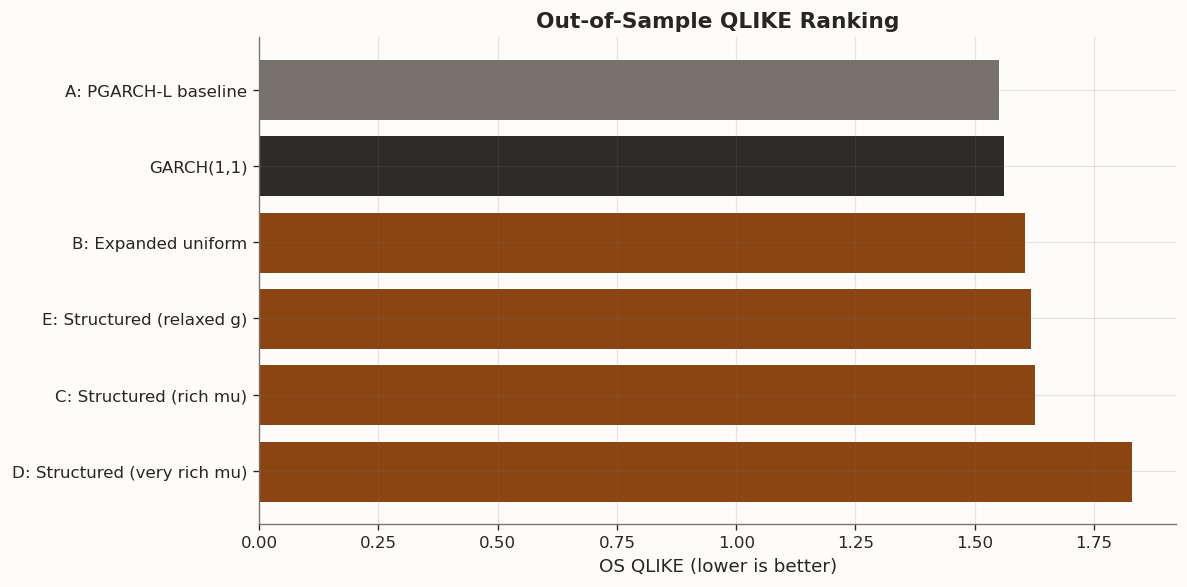

In [8]:
#| code-fold: true
#| code-summary: "OS QLIKE ranking bar chart"

chart_df = results_df[["OS QLIKE"]].sort_values("OS QLIKE")

_colors = {
    "GARCH(1,1)": BLOG_PALETTE[2],
    "A: PGARCH-L baseline": BLOG_PALETTE[3],
}
bar_colors = [_colors.get(idx, BLOG_PALETTE[0]) for idx in chart_df.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(chart_df.index, chart_df["OS QLIKE"], color=bar_colors,
               edgecolor="white", linewidth=0.6)
ax.set_xlabel("OS QLIKE (lower is better)")
ax.set_title("Out-of-Sample QLIKE Ranking", fontsize=13, fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Formal Comparison

As in [Part 4](../volatility-forecasts-4/) and [Part 5](../volatility-forecasts-5/), we use Diebold-Mariano tests on QLIKE and squared-error loss differentials to check whether the visible ranking differences are statistically meaningful ([background](../forecast-comparison/)). The key pairwise comparisons are: Model C vs `GARCH(1,1)` (does structured allocation clear the benchmark?), Model C vs Model A (does expansion beat the family baseline?), and Model D vs Model C (does extra $\mu$ freedom help?).

In [9]:
#| code-fold: true
#| code-summary: "Diebold-Mariano tests"

def _qlike_loss(y, yhat):
    y_a, h_a = np.asarray(y, float), np.maximum(np.asarray(yhat, float), 1e-12)
    return np.log(h_a) + y_a / h_a

def _sq_loss(y, yhat):
    return (np.asarray(y, float) - np.asarray(yhat, float)) ** 2

dm_pairs = [
    ("C: Structured (rich mu)", "GARCH(1,1)"),
    ("C: Structured (rich mu)", "A: PGARCH-L baseline"),
    ("C: Structured (rich mu)", "B: Expanded uniform"),
    ("C: Structured (rich mu)", "E: Structured (relaxed g)"),
    ("D: Structured (very rich mu)", "C: Structured (rich mu)"),
    ("B: Expanded uniform", "A: PGARCH-L baseline"),
]

dm_rows = []
for loss_name, loss_fn in [("QLIKE", _qlike_loss), ("Squared", _sq_loss)]:
    for name_a, name_b in dm_pairs:
        _, pred_a = model_predictions[name_a]
        _, pred_b = model_predictions[name_b]
        loss_a = loss_fn(actual_os, pred_a)
        loss_b = loss_fn(actual_os, pred_b)
        dm_result = diebold_mariano(loss_a, loss_b)
        dm_rows.append({
            "Loss": loss_name,
            "Model A": name_a,
            "Model B": name_b,
            "DM stat": dm_result["dm_stat"],
            "p-value": dm_result["p_value"],
            "Mean diff": dm_result["mean_d"],
        })

dm_df = pd.DataFrame(dm_rows)
display(style_results_table(dm_df, precision=4, index_col="Model A"))

,Loss,Model B,DM stat,p-value,Mean diff
Model A,,,,,
C: Structured (rich mu),QLIKE,"GARCH(1,1)",1.5542,0.1203,0.0645
C: Structured (rich mu),QLIKE,A: PGARCH-L baseline,1.9879,0.0470,0.0754
C: Structured (rich mu),QLIKE,B: Expanded uniform,1.5350,0.1249,0.0208
C: Structured (rich mu),QLIKE,E: Structured (relaxed g),0.9508,0.3418,0.0086
D: Structured (very rich mu),QLIKE,C: Structured (rich mu),2.6157,0.0090,0.2049
B: Expanded uniform,QLIKE,A: PGARCH-L baseline,1.4995,0.1339,0.0546
C: Structured (rich mu),Squared,"GARCH(1,1)",1.1749,0.2402,0.0000
C: Structured (rich mu),Squared,A: PGARCH-L baseline,1.1684,0.2428,0.0000
C: Structured (rich mu),Squared,B: Expanded uniform,1.0585,0.2899,0.0000


The DM tests organize the evidence into three stories.

1. **Model C vs `GARCH(1,1)` — wrong direction.** DM = 1.55 (p = 0.12) under QLIKE. The structured all-feature specification is not merely failing to clear the benchmark; the loss differential points in the wrong direction. The expansion makes the forecast worse, not better.

2. **Model C vs Model A — significantly worse than the family baseline.** DM = 1.99 (p = 0.047). The expanded variant is statistically worse than the three-feature `PGARCH-L` on this split. The additional features add estimation noise that QLIKE penalizes.

3. **Model D vs Model C — more $\mu$ freedom amplifies overfitting.** DM = 2.62 (p = 0.009). Loosening the level channel further does not uncover additional signal. In this linear setup, the extra freedom amplifies overfitting rather than extracting a useful slow-moving anchor.

Uniform regularization (Model B) does not improve on the baseline either, and relaxing the $g$ penalty (Model E) does not rescue the expanded design. The linear expansion branch is exhausted under the current protocol.

## Channel Diagnostics

One advantage of PGARCH over a single-gate model is that it exposes $\mu_t$, $\phi_t$, and $g_t$ as separate time-varying quantities. Even when the expanded models do not improve the forecast, the channel decomposition reveals *how* the richer features change the structural dynamics.

We expect the structured models to show more variation in $\mu_t$ (the level anchor absorbs cross-asset and macro information), comparable persistence in $\phi_t$, and a more stable $g_t$ path where the innovation-share penalty is kept high.

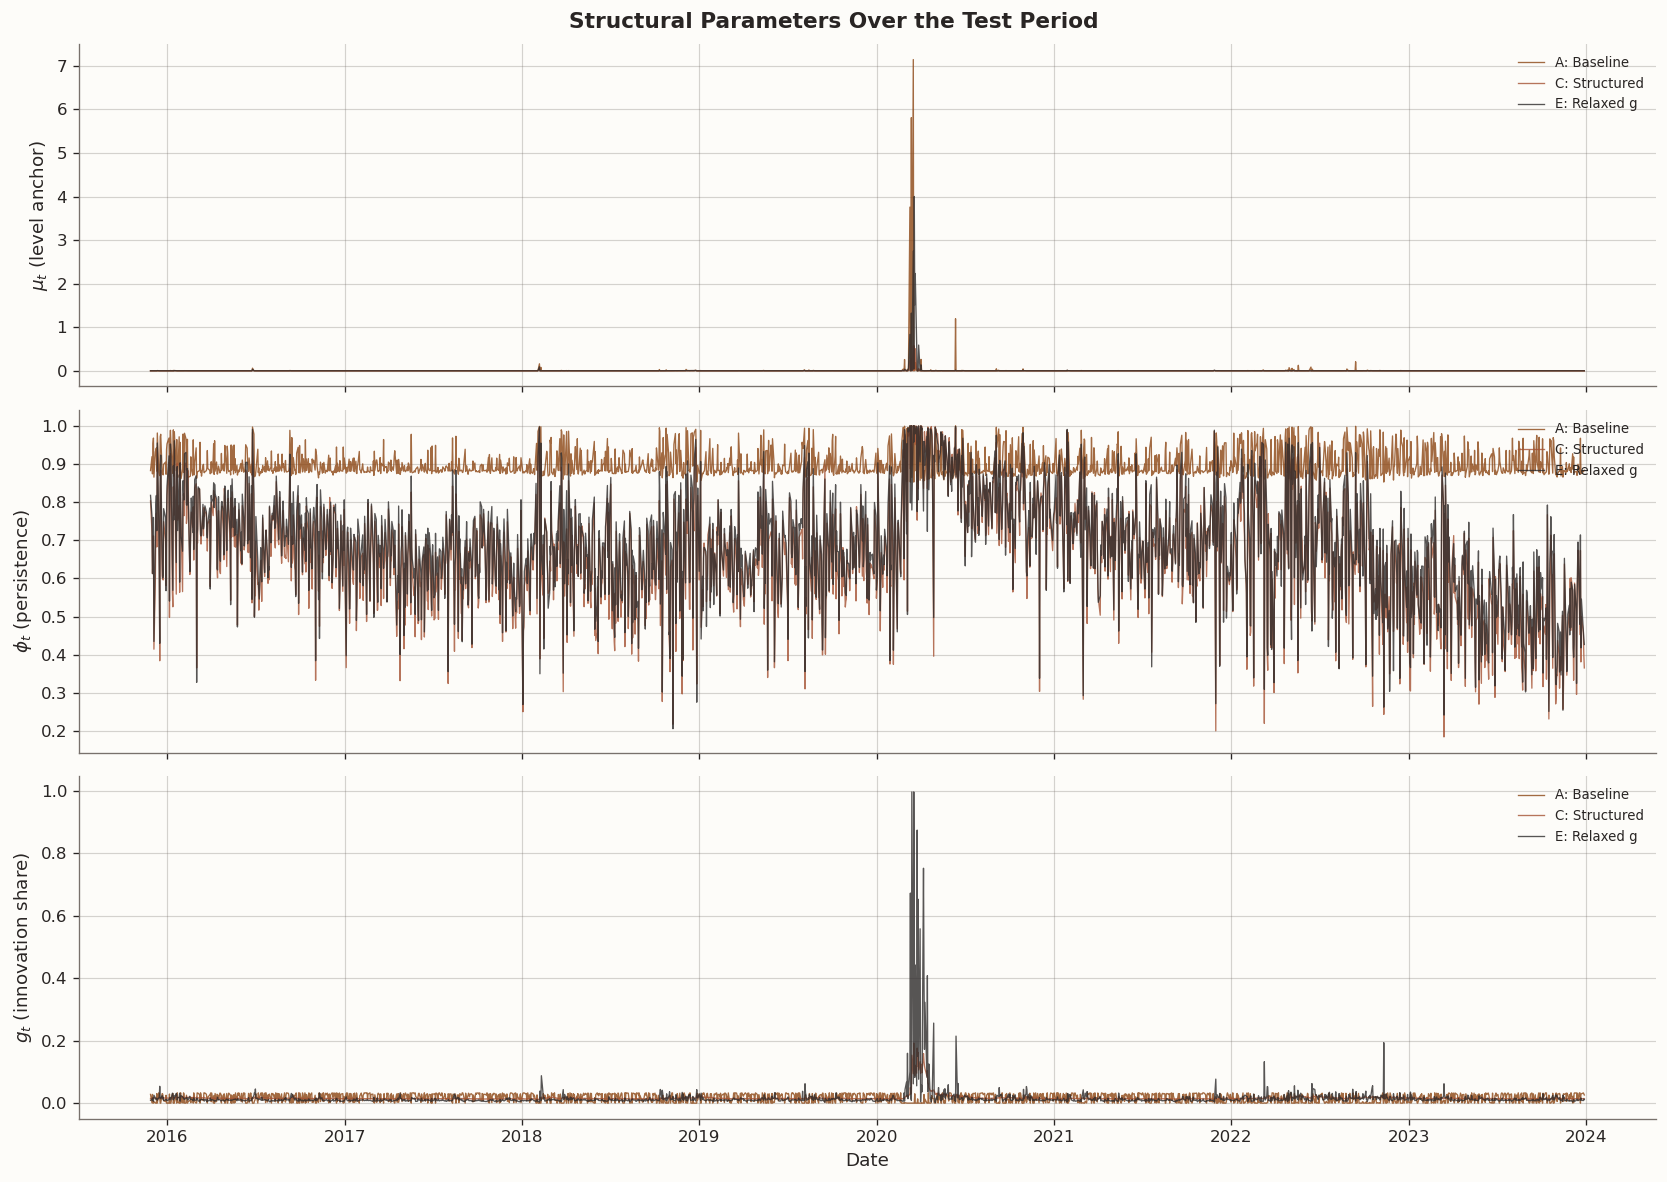

In [10]:
#| code-fold: true
#| code-summary: "Time-varying structural parameters: mu_t, phi_t, g_t over the test period"

# Extract components for Models A, C, and E over the out-of-sample period
models_to_plot = {
    "A: Baseline": (model_a, X_base_te),
    "C: Structured": (model_c, X_exp_te),
    "E: Relaxed g": (model_e, X_exp_te),
}

test_dates = y_te.index

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
channel_names = ["mu", "phi", "g"]
channel_labels = [r"$\mu_t$ (level anchor)", r"$\phi_t$ (persistence)", r"$g_t$ (innovation share)"]

for i, (ch, ch_label) in enumerate(zip(channel_names, channel_labels)):
    ax = axes[i]
    for j, (label, (mod, X_mod)) in enumerate(models_to_plot.items()):
        comps = mod.predict_components(X_mod.values)
        ax.plot(test_dates, comps[ch], label=label, color=BLOG_PALETTE[j],
                alpha=0.8, linewidth=0.8)
    ax.set_ylabel(ch_label)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle("Structural Parameters Over the Test Period", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [11]:
#| code-fold: true
#| code-summary: "Channel summary statistics (test period)"

summary_rows = []
for label, (mod, X_mod) in models_to_plot.items():
    comps = mod.predict_components(X_mod.values)
    for ch in ["mu", "phi", "g"]:
        vals = comps[ch]
        summary_rows.append({
            "Model": label,
            "Channel": ch,
            "Mean": np.mean(vals),
            "Std": np.std(vals),
            "Min": np.min(vals),
            "Max": np.max(vals),
            "CV": np.std(vals) / max(np.mean(vals), 1e-12),
        })

summary_df = pd.DataFrame(summary_rows)
display(style_results_table(summary_df, precision=6, index_col="Model"))

,Channel,Mean,Std,Min,Max,CV
Model,,,,,,
A: Baseline,mu,0.010582,0.222744,0.000000,7.145285,21.048554
A: Baseline,phi,0.900027,0.034148,0.852346,0.999900,0.037941
A: Baseline,g,0.016393,0.013172,0.000100,0.033033,0.803523
C: Structured,mu,0.001366,0.022692,0.000000,0.567997,16.611257
C: Structured,phi,0.655306,0.145465,0.185111,0.999899,0.221981
C: Structured,g,0.017005,0.011875,0.011064,0.192339,0.698296
E: Relaxed g,mu,0.007274,0.129225,0.000000,4.001123,17.766155
E: Relaxed g,phi,0.677347,0.141967,0.206599,0.999900,0.209592
E: Relaxed g,g,0.017523,0.052603,0.002309,0.995919,3.001913


## Coefficient and Allocation Diagnostics

Differential shrinkage should steer features toward their intended channels: cross-asset and macro predictors toward $\mu$, volatility-state features toward $\phi$, and fast return features toward $g$. The coefficient heatmap and allocation-score table below test whether that steering is visible in the fitted weights of Model C.

In [12]:
#| code-fold: true
#| code-summary: "Per-channel coefficient analysis for Model C"

def _extract_channel_coefs(model, feat_cols):
    '''Extract per-channel coefficients (on the standardised scale).'''
    theta = model.theta_
    block = len(theta) // 3
    # First element of each block is the intercept
    w_mu = theta[:block]
    w_phi = theta[block:2*block]
    w_g = theta[2*block:]
    # Skip intercept (index 0)
    return pd.DataFrame({
        "Feature": feat_cols,
        "Group": [_assign_group(f) for f in feat_cols],
        "Primary channel": [_assign_channel(f) for f in feat_cols],
        "w_mu": w_mu[1:],
        "w_phi": w_phi[1:],
        "w_g": w_g[1:],
        "|w_mu|": np.abs(w_mu[1:]),
        "|w_phi|": np.abs(w_phi[1:]),
        "|w_g|": np.abs(w_g[1:]),
    })


coef_df = _extract_channel_coefs(model_c, expanded_feat_cols)

# Top features per channel
for ch, label in [("mu", "mu (level)"), ("phi", "phi (persistence)"), ("g", "g (innovation)")]:
    print(f"\n{'='*60}")
    print(f"Top 15 features in {label} channel (|w_{ch}|):")
    print(f"{'='*60}")
    top = coef_df.nlargest(15, f"|w_{ch}|")[["Feature", "Group", "Primary channel", f"w_{ch}", f"|w_{ch}|"]]
    print(top.to_string(index=False))


Top 15 features in mu (level) channel (|w_mu|):
                   Feature             Group   Primary channel      w_mu   |w_mu|
                 vix_level VIX / Implied Vol        mu (level)  0.768359 0.768359
   lag.logret.fc5d3612d9c7      Return-based    g (innovation) -0.604354 0.604354
           intraday_return   Intraday Decomp    g (innovation) -0.523866 0.523866
 lag.sqlogret.c2cf3aa70c10      Return-based    g (innovation) -0.399809 0.399809
          overnight_return   Intraday Decomp    g (innovation) -0.313615 0.313615
lag.abslogret.1ad490bcb584      Return-based    g (innovation) -0.310394 0.310394
                      rv_5  Volatility State phi (persistence)  0.281547 0.281547
               rv_range_22  Volatility State phi (persistence) -0.233714 0.233714
                     dow_4    Calendar (DOW)        mu (level)  0.224715 0.224715
          long_rate_change       Cross-Asset        mu (level) -0.223479 0.223479
                     dow_3    Calendar (DOW)     

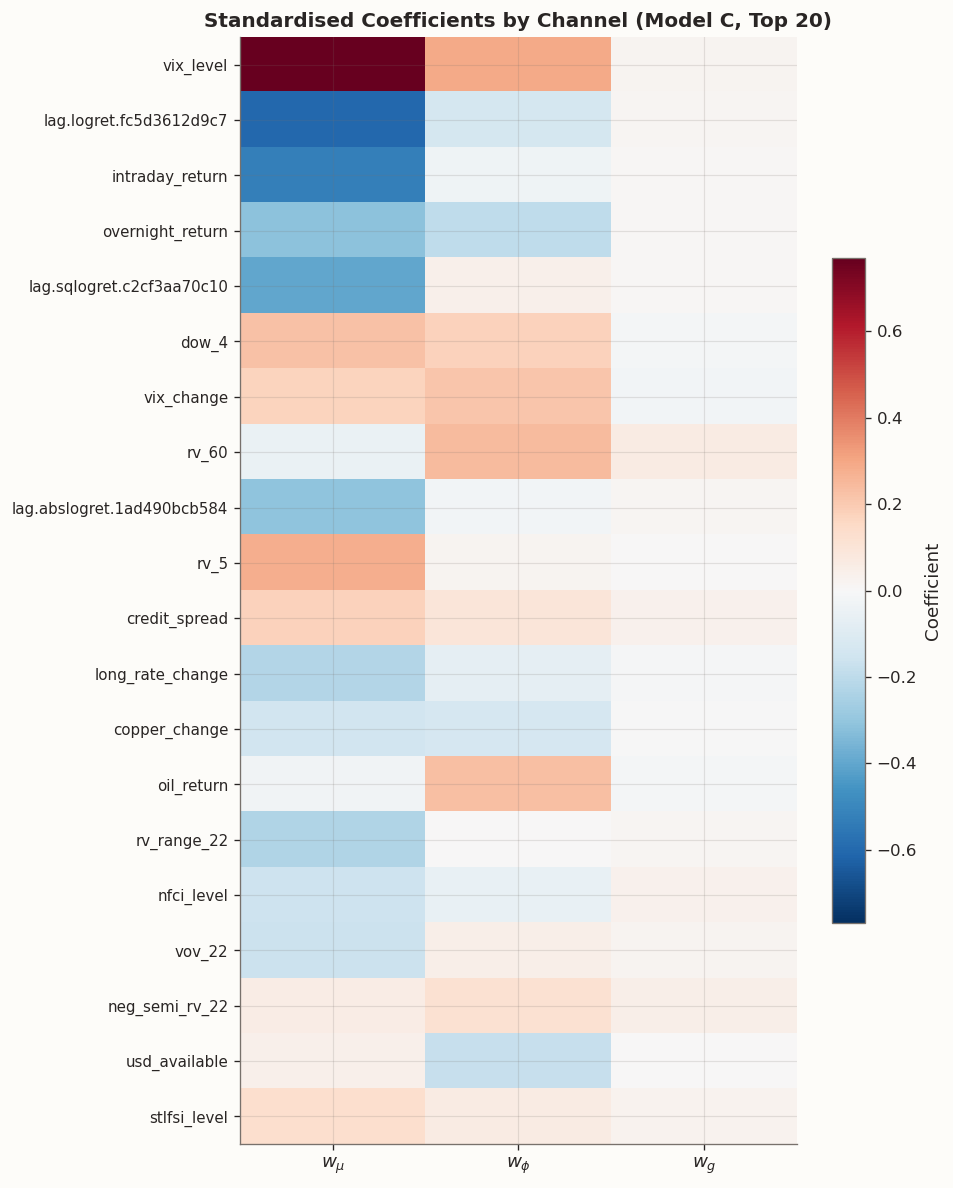

In [13]:
#| code-fold: true
#| code-summary: "Channel coefficient heatmap (top 20 features by total importance)"

coef_df["total_importance"] = coef_df["|w_mu|"] + coef_df["|w_phi|"] + coef_df["|w_g|"]
top20 = coef_df.nlargest(20, "total_importance")

fig, ax = plt.subplots(figsize=(8, 10))
data_to_plot = top20[["w_mu", "w_phi", "w_g"]].values
feat_labels = top20["Feature"].values

im = ax.imshow(data_to_plot, cmap="RdBu_r", aspect="auto",
               vmin=-np.abs(data_to_plot).max(), vmax=np.abs(data_to_plot).max())
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([r"$w_\mu$", r"$w_\phi$", r"$w_g$"], fontsize=11)
ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, fontsize=9)
ax.set_title("Standardised Coefficients by Channel (Model C, Top 20)", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.6, label="Coefficient")
fig.tight_layout()
plt.show()

In [14]:
#| code-fold: true
#| code-summary: "Validate channel allocation: fraction of weight in primary vs other channels"

def _allocation_score(row):
    '''Fraction of total absolute weight in the primary channel.'''
    total = row["|w_mu|"] + row["|w_phi|"] + row["|w_g|"]
    if total < 1e-12:
        return np.nan
    ch_map = {"g (innovation)": "|w_g|", "phi (persistence)": "|w_phi|", "mu (level)": "|w_mu|"}
    primary_col = ch_map.get(row["Primary channel"], "|w_mu|")
    return row[primary_col] / total

coef_df["allocation_score"] = coef_df.apply(_allocation_score, axis=1)

# Group-level summary
alloc_summary = coef_df.groupby("Primary channel").agg(
    n_features=("Feature", "count"),
    mean_alloc=("allocation_score", "mean"),
    median_alloc=("allocation_score", "median"),
    mean_total_w=("total_importance", "mean"),
).round(4)

print("Allocation validation: fraction of weight in the intended channel")
print("(higher = regularisation is steering features as intended)\n")
display(style_results_table(alloc_summary, precision=4, index_col="Primary channel"))

Allocation validation: fraction of weight in the intended channel
(higher = regularisation is steering features as intended)



,n_features,mean_alloc,median_alloc,mean_total_w
Primary channel,,,,
g (innovation),8,0.0774,0.0338,0.3627
mu (level),35,0.4172,0.3387,0.1738
phi (persistence),11,0.3647,0.3217,0.2030


The structured models move more variation into $\mu_t$ and $\phi_t$ and keep $g_t$ more stable when its penalty is high. The allocation-score table, however, shows the limit: shrinkage alone does not produce a clean channel separation, especially for features intended for the innovation channel. The structural prior is only partially enforced, which helps explain why interpretability improved more than forecast accuracy.

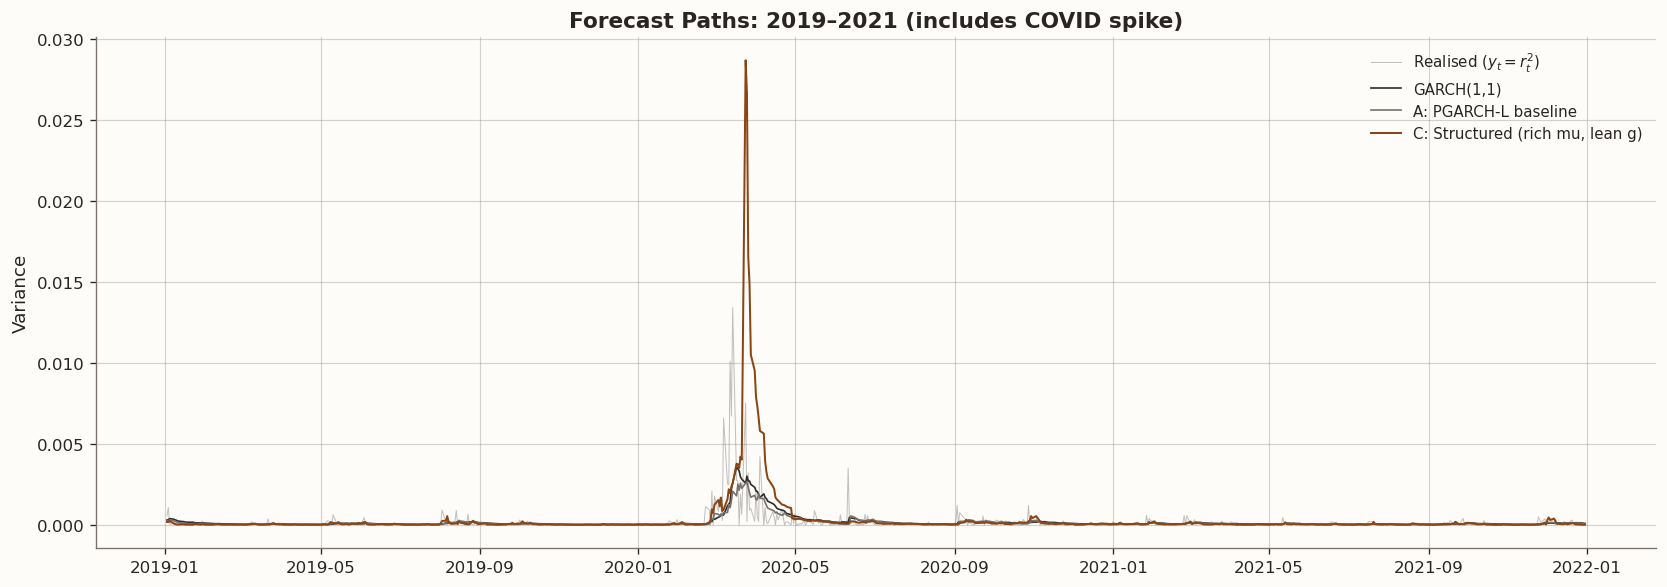

In [15]:
#| code-fold: true
#| code-summary: "Forecast paths: GARCH vs PGARCH-L baseline vs Structured (2019-2021 window)"

window_start = pd.Timestamp("2019-01-01", tz="UTC")
window_end = pd.Timestamp("2021-12-31", tz="UTC")

test_dates = y_te.index
mask = (test_dates >= window_start) & (test_dates <= window_end)
plot_dates = test_dates[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dates, y_te.values[mask], label="Realised ($y_t = r_t^2$)",
        color=BLOG_PALETTE[4], alpha=0.4, linewidth=0.6)
ax.plot(plot_dates, garch_pred_os[mask], label="GARCH(1,1)",
        color=BLOG_PALETTE[2], linewidth=1.0)
ax.plot(plot_dates, h_a_os[mask], label="A: PGARCH-L baseline",
        color=BLOG_PALETTE[3], linewidth=1.0)
ax.plot(plot_dates, h_c_os[mask], label="C: Structured (rich mu, lean g)",
        color=BLOG_PALETTE[0], linewidth=1.2)

ax.set_ylabel("Variance")
ax.set_title("Forecast Paths: 2019–2021 (includes COVID spike)", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Nonlinear Preview

If the linear expansion has stalled, does a nonlinear channel update fare better? The full `XGBPGARCHModel` replaces the linear maps in all three channels with gradient-boosted trees, using a PGARCH-L initialization.

On the expanded feature set, the default `linear_pgarch` initializer fails before the boosted comparison can proceed. The result is a boundary marker rather than a verdict: once the feature set is wide enough, the nonlinear PGARCH line depends on initialization discipline before any substantive comparison is possible.

In [16]:
#| code-fold: true
#| code-summary: "Fit full XGBPGARCHModel (optional — may be slow)"

try:
    from volatility_forecast.model.xgb_pgarch_full_model import XGBPGARCHModel

    y_tr_scaled = y_tr.values * (SCALE_FACTOR ** 2)
    y_all_scaled = y_all.values * (SCALE_FACTOR ** 2)

    xgb_full = XGBPGARCHModel(
        loss="qlike",
        n_outer_rounds=25,
        trees_per_channel_per_round=1,
        learning_rate=0.02,
        max_depth=3,
        min_child_weight=5.0,
        reg_lambda=1.0,
        init_method="linear_pgarch",
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    xgb_full.fit(y_tr_scaled, X_exp_tr)
    h_xgb_full_scaled = xgb_full.predict_variance(y_all_scaled, X_exp_all)
    h_xgb_full = h_xgb_full_scaled / (SCALE_FACTOR ** 2)
    h_xgb_full_is = h_xgb_full[:len(y_tr)]
    h_xgb_full_os = h_xgb_full[len(y_tr):]

    xgb_full_rmse_os = rmse(actual_os, h_xgb_full_os)
    xgb_full_qlike_os = qlike(actual_os, h_xgb_full_os)
    print(f"XGBPGARCHModel (full): OS RMSE = {xgb_full_rmse_os:.6f}, OS QLIKE = {xgb_full_qlike_os:.6f}")

    # DM test vs Model C
    loss_xgb = _qlike_loss(actual_os, h_xgb_full_os)
    loss_c = _qlike_loss(actual_os, h_c_os)
    dm_xgb_vs_c = diebold_mariano(loss_xgb, loss_c)
    print(f"DM (XGBPGARCHModel vs Model C, QLIKE): stat={dm_xgb_vs_c['dm_stat']:.3f}, p={dm_xgb_vs_c['p_value']:.3f}")

    _xgb_full_available = True
except Exception as e:
    print(f"XGBPGARCHModel comparison skipped: {e}")
    _xgb_full_available = False

XGBPGARCHModel comparison skipped: PGARCHLinearModel optimization failed: restart=0: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


In [17]:
#| code-fold: true
#| code-summary: "Final combined results table"

final_rows = list(rows)  # from the earlier performance table
if _xgb_full_available:
    final_rows.append({
        "Model": "F: XGBPGARCHModel (full)",
        "IS RMSE": rmse(actual_is, h_xgb_full_is),
        "OS RMSE": xgb_full_rmse_os,
        "IS QLIKE": qlike(actual_is, h_xgb_full_is),
        "OS QLIKE": xgb_full_qlike_os,
    })

final_df = pd.DataFrame(final_rows).set_index("Model")
final_df = final_df.sort_values("OS QLIKE")
display(style_results_table(final_df, precision=6, index_col="Model"))

,IS RMSE,OS RMSE,IS QLIKE,OS QLIKE
Model,,,,
A: PGARCH-L baseline,0.000483,0.000459,1.456357,1.550144
"GARCH(1,1)",0.000504,0.000460,1.513060,1.561044
B: Expanded uniform,0.000462,0.000855,1.401546,1.604755
E: Structured (relaxed g),0.000473,0.001533,1.395647,1.616961
C: Structured (rich mu),0.000464,0.001051,1.399849,1.625556
D: Structured (very rich mu),0.000456,0.000949,1.396102,1.830423


## Conclusion

The Part 5 baseline model `PGARCH-L` with three return features remains the best OS QLIKE forecast (1.550) across all variants. Expanding the feature set from 3 to 54 columns improves in-sample fit uniformly while degrading every out-of-sample score. The binding constraint is controlling how richer information enters the recursion without paying too much estimation variance.

Moreover, differential shrinkage steers features partially but not cleanly. The channel diagnostics show that structured regularization moves more variation into $\mu_t$ and stabilizes $g_t$, matching the intended allocation prior. The allocation-score table, however, shows only partial enforcement — especially for features intended for the innovation channel. Interpretability improved more than forecast accuracy.

Finally, the full `XGBPGARCHModel` preview fails at initialization on the expanded design, identifying a concrete technical obstacle rather than evidence against the nonlinear branch.

The expanded linear variants do not clear `GARCH(1,1)`, and regularization alone cannot produce the clean channel separation the structural story requires. These are real limitations that bound the Part 6 contribution to diagnostics and motivation rather than a benchmark result.

### What's next

[Part 7](../volatility-forecasts-7/) broadens the specification search while keeping the benchmark, target, and QLIKE-based decision rule fixed. The questions shift from whether richer structure can help in principle to which richer structure — if any — survives alternative feature allocations, narrower screened subsets, better initialization, and stronger robustness checks.

## Appendix: Implied GARCH Parameters

For interpretability, we convert the structured PGARCH-L coefficients into implied $\omega_t = (1-\phi_t)\mu_t$, $\alpha_t = \phi_t g_t$, and $\beta_t = \phi_t(1-g_t)$ and report their test-period statistics.

In [18]:
#| code-fold: true
#| code-summary: "Implied GARCH parameters for selected models"

impl_rows = []
for label, (mod, X_mod) in models_to_plot.items():
    impl = mod.implied_garch_params(X_mod.values)
    for param in ["omega", "alpha", "beta"]:
        vals = impl[param]
        impl_rows.append({
            "Model": label,
            "Parameter": param,
            "Mean": np.mean(vals),
            "Std": np.std(vals),
            "Min": np.min(vals),
            "Max": np.max(vals),
        })

impl_df = pd.DataFrame(impl_rows)
display(style_results_table(impl_df, precision=6, index_col="Model"))

# Comparison with static GARCH(1,1)
print(f"\nStatic GARCH(1,1) parameters for reference:")
print(f"  omega = {omega_g:.6f}")
print(f"  alpha = {alpha_g:.4f}")
print(f"  beta  = {beta_g:.4f}")

,Parameter,Mean,Std,Min,Max
Model,,,,,
A: Baseline,omega,0.000012,0.000040,0.000000,0.000718
A: Baseline,alpha,0.014430,0.011562,0.000085,0.029005
A: Baseline,beta,0.885597,0.043223,0.848145,0.999800
C: Structured,omega,0.000041,0.000562,0.000000,0.025237
C: Structured,alpha,0.011545,0.011738,0.003229,0.190977
C: Structured,beta,0.643761,0.140861,0.181881,0.980462
E: Relaxed g,omega,0.000054,0.001054,0.000000,0.047439
E: Relaxed g,alpha,0.012324,0.044605,0.002128,0.952998
E: Relaxed g,beta,0.665023,0.143035,0.003352,0.994458



Static GARCH(1,1) parameters for reference:
  omega = 0.018841
  alpha = 0.0952
  beta  = 0.8899
